
# Bitácora — Franck–Hertz (Hg)
**Universidad de los Andes — Laboratorio Intermedio**  
**Fecha:** 2025-09-16 19:36  
**Estudiantes:** Ángela Bustos , Mariana Montoya. 
**Correos:** av.bustos@uniandes.edu.co , 

**Sitio de guardado:** https://github.com/ValentinaBustos2025/Lab-Intermedio.git (en la nube).

**Carpeta :** Fran Herz

**Archivo:** Bitácora.ipynb

<p align="center">
  <img src="guardado.jpg" alt="Mi imagen" width="600">
</p>

---
## Objetivos
- Medir la cuantización de la energía de estados electrónicos en átomos de Mercurio (Hg).
- Entender cómo la temperatura afecta la densidad del gas y el camino libre medio.
- Calcular la energía entre el estado base y el primer estado excitado del Hg.

---
## Marco Teórico

En 1914, James Franck y Gustav Hertz demostraron experimentalmente la **cuantización de la energía** en átomos de mercurio (Hg), validando la idea central de la teoría de **Bohr** (1913): los electrones en los átomos ocupan **niveles discretos** de energía y las transiciones entre ellos implican ganancias o pérdidas de paquetes de energía bien definidos.

### 1) Fundamentos de Bohr (contexto)
- Los electrones se mueven en **órbitas estacionarias** con energías cuantizadas.  
- La emisión/absorción de radiación ocurre cuando el electrón **salta** entre niveles con diferencia de energía **ΔE = hν**.  
- Aunque Bohr formuló su modelo para el hidrógeno, el hallazgo de Franck–Hertz mostró que la **cuantización** también se manifiesta en átomos multielectrónicos (como Hg) mediante impactos electrónicos.

### 2) Colisiones electrón–átomo en Hg
- **Elásticas:** el electrón cambia de dirección, pero la **energía cinética** total se conserva (la pérdida es despreciable debido a que $m_e \ll M_{\mathrm{Hg}}$).  

- **Inelásticas:** si la energía del electrón supera el umbral de excitación $E_a$, transfiere aproximadamente \(E_a\) al átomo (p. ej., 4.67 eV para el primer estado excitado relevante de Hg), dejando menos energía cinética remanente.

Como consecuencia, al **aumentar** el voltaje acelerador $U_1$, la corriente medida $I_A$ exhibe **mínimos periódicos**: en cada umbral, muchos electrones sufren colisiones inelásticas y **no** alcanzan el ánodo (o no superan $U_2$), produciendo una caída en $I_A$.

### 3) Rol de la temperatura y el camino libre medio
La **densidad** de átomos de Hg en el tubo depende de la **presión de vapor** y la **temperatura**. Modelando el Hg como gas ideal, $n = P/(k_B T)$. El **camino libre medio**,
\[
\bar{\ell} = \frac{1}{\sqrt{2}\,n\,\sigma},
\]
representa la distancia promedio entre colisiones electrón–átomo (con $\sigma \approx \pi r^2$ una sección eficaz efectiva).  
- Si $\bar{\ell} \ll L$ (siendo $L$ la distancia cátodo–ánodo), **se incrementa** la probabilidad de múltiples colisiones dentro del tubo y aparecen **varios** mínimos/ máximos en $I_A(U_1)$.  
- Si $\bar{\ell}$ es **comparable** a $L$, disminuye el número de colisiones y se **suprime** la estructura de picos.

### 4) Voltaje de retardo $U_2$ y emisión termoiónica $U_H$
- **\(U_2\)** (retardo) establece un umbral de energía: solo los electrones con energía cinética suficiente lo superan y contribuyen a \(I_A\). Al **aumentar** \(U_2\), se filtran más electrones de baja energía, lo que **desplaza** o **acentúa** los mínimos.  
- **\(U_H\)** (calentamiento del cátodo) controla la **emisión termoiónica** y la distribución de energías iniciales de los electrones (tipo Maxwell–Boltzmann). Cambios en \(U_H\) afectan la **amplitud** de \(I_A\), el **ancho** de valles/picos y la reproducibilidad.

### 5) Distancias entre mínimos y estimación de $E_a$ y $\bar{\ell}$
Denotando por $U_1^{(n)}$ la posición del **n-ésimo mínimo** de $I_A(U_1)$, la **separación** entre mínimos consecutivos $\Delta E(n) = U_1^{(n)} - U_1^{(n-1)}$ (en voltios ~ eV) crece débilmente con $n debido a que, con mayores $U_1$, el electrón gana energía adicional en cada tramo libre $\bar{\ell}$. Un modelo efectivo predice:
\[
\Delta E(n) \approx \left(1 + \frac{\bar{\ell}}{L}(2n-1)\right) E_a.
\]
- Ajustando $\Delta E(n)$ vs. $n$ se obtiene la **pendiente** que permite estimar $\bar{\ell}_{\mathrm{exp}}$.  
- Extrapolando a $n=1/2$, se estima $E_a \approx \Delta E(0.5)$, que se compara con el valor tabulado de Hg (~4.67 eV).

**Conclusión teórica:** la aparición de mínimos periódicos en $I_A(U_1)$ y su **separación característica** constituyen una verificación directa de la **cuantización** de los niveles atómicos. La sensibilidad de la curva a $T$, $U_2$ y $U_H$ habilita, además, la **caracterización** del medio (densidad/camino libre) y del proceso de emisión.


---

## Montaje Experimental
- Tubo de Franck-Hertz en estufa.  
- Módulo de control y medición (conexiones: UH, U1, U2).  
- Osciloscopio para modo XY.  
- Software *Phywe Measure 4* para adquisición de datos.  

Precauciones:  
- T < 190 °C.  
- U1 < 60 V, UH < 7 V, U2 < 3 V.  


<p align="center">
  <img src="montaje.jpg" alt="Mi imagen" width="600">
</p>

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from matplotlib.ticker import AutoMinorLocator


def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                
                continue

    return np.array(columnas)


---

## Actividad 1

1. Con la ayuda del osciloscopio puede medir aproximadamente la distancia entre los mínimos. ¿Concuerda esta distancia con los valores esperados?

Para la temperatura de 175°, el promedio de la diferencia entre mínimos para cada toma diferente es de 4.56V, el cuál es un valor cercano al esperado de 4.67V. 

2. Mueva los cursores del osciloscopio tal que uno de los picos quede centrado en el origen y apague la estufa. Describa el comportamiento de los picos a medida que disminuye la temperatura y justifique sus observaciones. No deje que baje a más de 160◦C y cuando sea necesario disminuya el voltaje máximo U1.

3. Describa que sucede con la curva observada si cambia el voltaje U2 a 1,5V o a 1V a una temperatura constante.

4. Para obtener los máximos y mínimos puede ir al menú Análisis y luego Análsis de curva. Controlando la sensibilidad del análisis para detectar m´aximos y m´ınimos y mostr´ando los en la gráfica puede obtener figuras como la Fig.8. Las figuras las puede guardar para su reporte y la serie de datos, así como la información de máximos y mínimos la puede guardar/exportar para su posterior an´alisis. Si quiere guardar la serie completa de datos vaya a File y de clic en la opción Imprimir Datos. El software lo puede descargar libremente
para abrir las series de datos y poder realizar las gráficas pedidas para el informe.

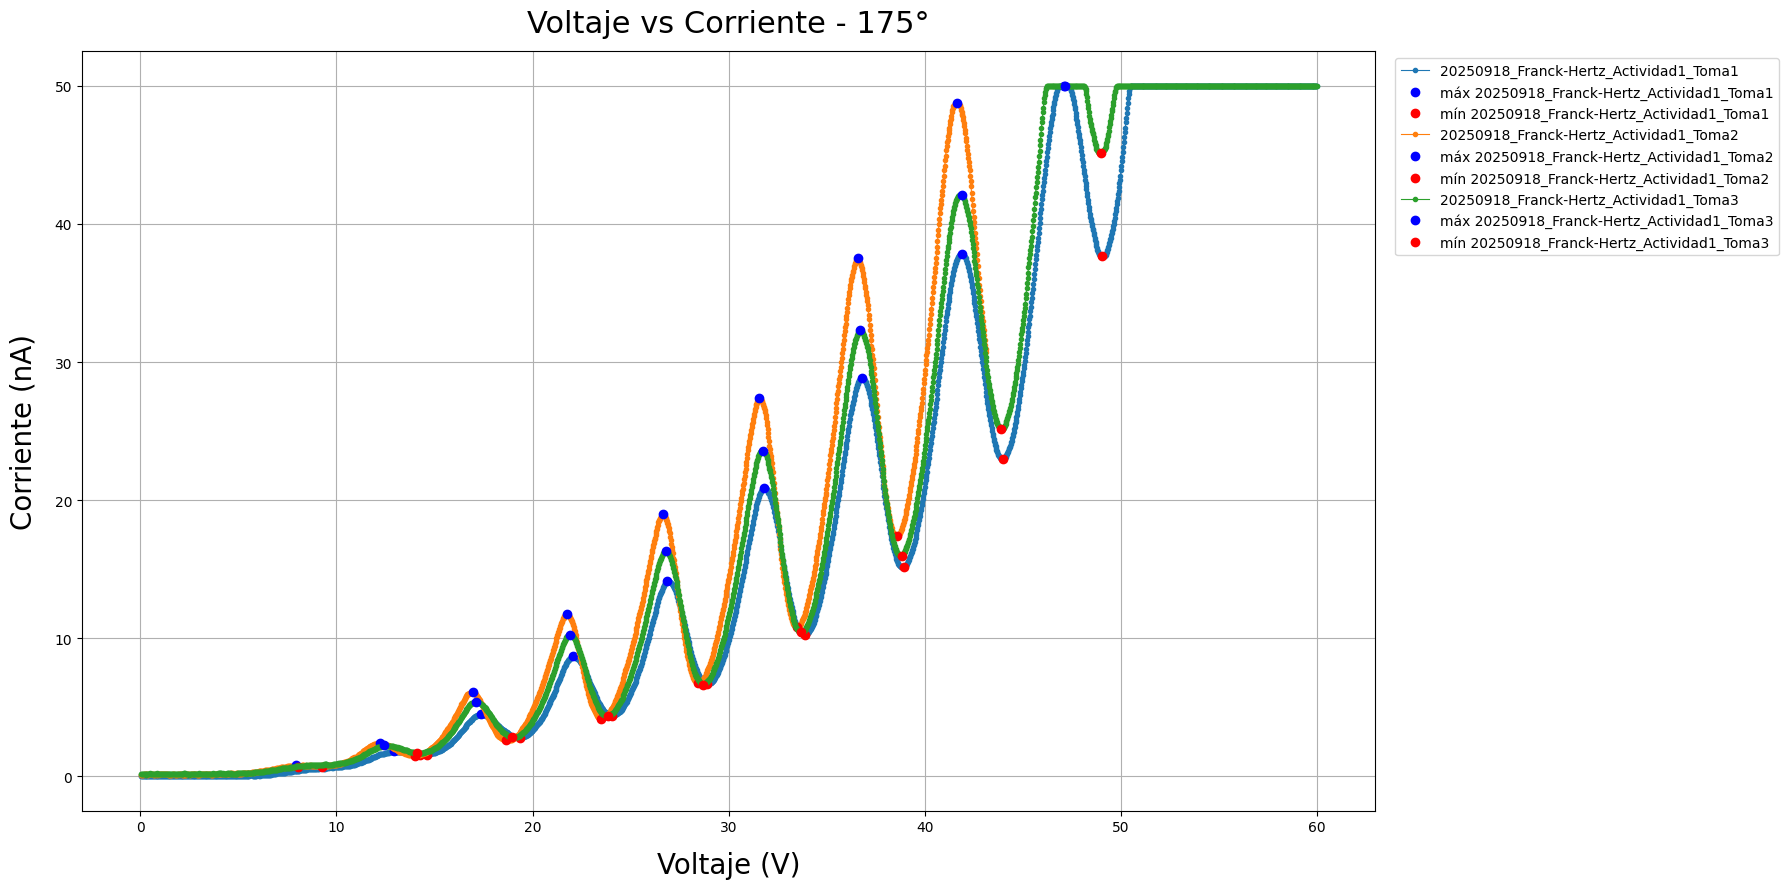

In [2]:
carpeta = Path("Data/Act1/175°")

fig, ax = plt.subplots(figsize=(18, 9))

# lista para guardar todos los valores detectados
valores_detectados = []

for archivo in carpeta.glob("*.txt"):
    voltajes = []
    corrientes = []
    with open(archivo, "r", encoding="utf-8") as f:
        try:
            next(f); next(f)  # saltar encabezados
        except StopIteration:
            pass
        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if voltajes:
        voltajes = np.array(voltajes)
        corrientes = np.array(corrientes)

        # --- detectar máximos y mínimos ---
        indices_max, _ = find_peaks(corrientes, distance=5, prominence=0.1)
        indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

        # guardar valores detectados en formato tabla
        #for idx in indices_max:
            #valores_detectados.append(("máximo", voltajes[idx], corrientes[idx]))
        #for idx in indices_min:
            #valores_detectados.append(("mínimo", voltajes[idx], corrientes[idx]))

        # --- graficar ---
        ax.plot(voltajes, corrientes, marker="o", markersize=3,
                linewidth=0.8, label=archivo.stem)
        ax.plot(voltajes[indices_max], corrientes[indices_max], "bo", markersize=6, label=f"máx {archivo.stem}")
        ax.plot(voltajes[indices_min], corrientes[indices_min], "ro", markersize=6, label=f"mín {archivo.stem}")

        # etiquetar puntos
        #for idx in np.concatenate([indices_max, indices_min]):
         #   ax.text(voltajes[idx], corrientes[idx], f"{corrientes[idx]:.2f}",
          #          fontsize=10, ha='center', va='bottom')

# Etiquetas y título
ax.set_xlabel("Voltaje (V)", fontsize=20, labelpad=12)
ax.set_ylabel("Corriente (nA)", fontsize=20, labelpad=12)
ax.set_title("Voltaje vs Corriente - 175°", fontsize=22, pad=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()





Archivo: 20250918_Franck-Hertz_Actividad1_Toma1
  Mínimo 0 -> 1: ΔV = 0.3400 V, ΔI = 0.0000 nA
  Mínimo 1 -> 2: ΔV = 4.7400 V, ΔI = 1.2300 nA
  Mínimo 2 -> 3: ΔV = 4.7100 V, ΔI = 1.5800 nA
  Mínimo 3 -> 4: ΔV = 4.8400 V, ΔI = 2.3000 nA
  Mínimo 4 -> 5: ΔV = 4.9600 V, ΔI = 3.5400 nA
  Mínimo 5 -> 6: ΔV = 5.0500 V, ΔI = 4.9200 nA
  Mínimo 6 -> 7: ΔV = 5.0800 V, ΔI = 7.8400 nA
  Mínimo 7 -> 8: ΔV = 5.0500 V, ΔI = 14.6900 nA

Archivo: 20250918_Franck-Hertz_Actividad1_Toma2
  Mínimo 0 -> 1: ΔV = 1.2200 V, ΔI = 0.0000 nA
  Mínimo 1 -> 2: ΔV = 4.7200 V, ΔI = 0.7800 nA
  Mínimo 2 -> 3: ΔV = 4.6600 V, ΔI = 1.1100 nA
  Mínimo 3 -> 4: ΔV = 4.8600 V, ΔI = 1.5900 nA
  Mínimo 4 -> 5: ΔV = 4.9300 V, ΔI = 2.5500 nA
  Mínimo 5 -> 6: ΔV = 5.0600 V, ΔI = 4.0700 nA
  Mínimo 6 -> 7: ΔV = 5.0800 V, ΔI = 6.6000 nA

Archivo: 20250918_Franck-Hertz_Actividad1_Toma3
  Mínimo 0 -> 1: ΔV = 4.8800 V, ΔI = 1.1400 nA
  Mínimo 1 -> 2: ΔV = 4.8600 V, ΔI = 1.5400 nA
  Mínimo 2 -> 3: ΔV = 4.8600 V, ΔI = 2.2800 nA
  Míni

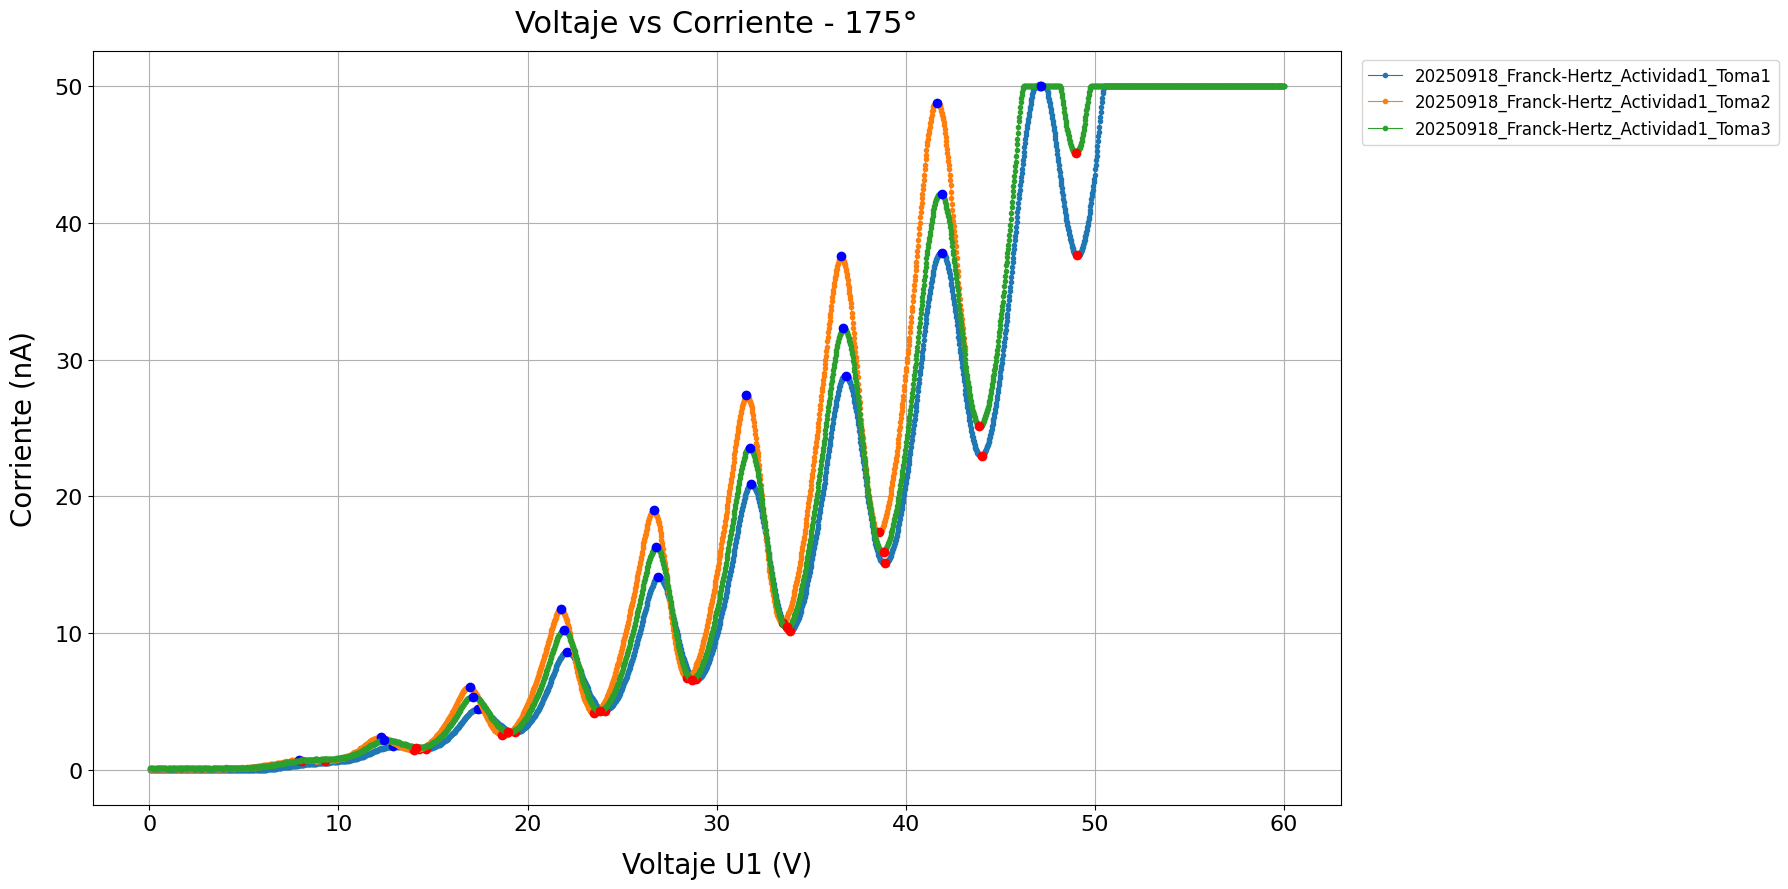

In [ ]:
# Carpeta donde están tus archivos
carpeta = Path("Data/Act1/175°")

fig, ax = plt.subplots(figsize=(18, 9))

# Guardar resultados de cada archivo
resultados = {}

for archivo in carpeta.glob("*.txt"):
    voltajes = []
    corrientes = []
    with open(archivo, "r", encoding="utf-8") as f:
        # Saltar encabezados
        try:
            next(f); next(f)
        except StopIteration:
            pass
        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if not voltajes:
        continue

    voltajes = np.array(voltajes)
    corrientes = np.array(corrientes)

    # Detectar máximos y mínimos
    indices_max, _ = find_peaks(corrientes, distance=5, prominence=0.1)
    indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

    # Guardar datos del archivo
    resultados[archivo.stem] = {
        "voltajes": voltajes,
        "corrientes": corrientes,
        "indices_max": indices_max,
        "indices_min": indices_min,
    }

    # Graficar la curva
    ax.plot(voltajes, corrientes, marker="o", markersize=3,
            linewidth=0.8, label=archivo.stem)

    # Marcar máximos y mínimos
    ax.plot(voltajes[indices_max], corrientes[indices_max], "bo", markersize=6)
    ax.plot(voltajes[indices_min], corrientes[indices_min], "ro", markersize=6)

    # Calcular diferencias entre mínimos consecutivos
    if len(indices_min) > 1:
        dif_volt = np.diff(voltajes[indices_min])
        dif_corr = np.diff(corrientes[indices_min])
        print(f"\nArchivo: {archivo.stem}")
        for i in range(len(dif_volt)):
            print(f"  Mínimo {i} -> {i+1}: ΔV = {dif_volt[i]:.4f} V, ΔI = {dif_corr[i]:.4f} nA")

# Configuración de la gráfica
ax.set_xlabel("Voltaje U1 (V)", fontsize=20, labelpad=12)
ax.set_ylabel("Corriente (nA)", fontsize=20, labelpad=12)
ax.set_title("Voltaje vs Corriente - 175°", fontsize=22, pad=14)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

# --- Comparación de picos entre archivos ---
# Cambia estos nombres por los de tus archivos reales
name_ref = "medicion_U2_0"   # archivo con U2=0 V
name_new = "medicion_U2_1p5" # archivo con U2=1.5 V

if name_ref in resultados and name_new in resultados:
    ref = resultados[name_ref]
    new = resultados[name_new]

    if len(ref["indices_max"]) > 0 and len(new["indices_max"]) > 0:
        # Tomar el primer pico máximo como referencia
        idx_ref = ref["indices_max"][0]
        idx_new = new["indices_max"][0]
        pos_ref = ref["voltajes"][idx_ref]
        pos_new = new["voltajes"][idx_new]
        desplazamiento = pos_new - pos_ref
        print(f"\nComparación de picos entre {name_ref} y {name_new}:")
        print(f"  Pos ref: {pos_ref:.3f} V, Pos new: {pos_new:.3f} V")
        print(f"  Desplazamiento Δ = {desplazamiento:.3f} V")
    else:
        print("\nNo se detectaron picos en uno de los archivos para la comparación.")



Archivo: 20250918_Franck-Hertz_Actividad1_Toma1
  Mínimo 0 -> 1: ΔV = 11.9900 V, ΔI = 1.8700 nA
  Mínimo 1 -> 2: ΔV = 4.8600 V, ΔI = 1.5600 nA
  Mínimo 2 -> 3: ΔV = 4.9100 V, ΔI = 2.1900 nA
  Mínimo 3 -> 4: ΔV = 4.8600 V, ΔI = 3.3700 nA
  Mínimo 4 -> 5: ΔV = 5.0500 V, ΔI = 5.6100 nA
  Mínimo 5 -> 6: ΔV = 5.0600 V, ΔI = 9.5000 nA
  Mínimo 6 -> 7: ΔV = 5.1200 V, ΔI = 14.3600 nA

Archivo: 20250918_Franck-Hertz_Actividad1_Toma2
  Mínimo 0 -> 1: ΔV = 1.3900 V, ΔI = 0.0200 nA
  Mínimo 1 -> 2: ΔV = 10.3500 V, ΔI = 1.6400 nA
  Mínimo 2 -> 3: ΔV = 4.8100 V, ΔI = 1.3900 nA
  Mínimo 3 -> 4: ΔV = 4.8900 V, ΔI = 1.8600 nA
  Mínimo 4 -> 5: ΔV = 4.7600 V, ΔI = 2.8200 nA
  Mínimo 5 -> 6: ΔV = 5.0100 V, ΔI = 4.6400 nA
  Mínimo 6 -> 7: ΔV = 4.9300 V, ΔI = 7.6600 nA
  Mínimo 7 -> 8: ΔV = 5.2000 V, ΔI = 11.2900 nA

Archivo: 20250918_Franck-Hertz_Actividad1_Toma3
  Mínimo 0 -> 1: ΔV = 4.9000 V, ΔI = 1.3100 nA
  Mínimo 1 -> 2: ΔV = 4.8200 V, ΔI = 1.7600 nA
  Mínimo 2 -> 3: ΔV = 4.8300 V, ΔI = 2.6700 nA
  M

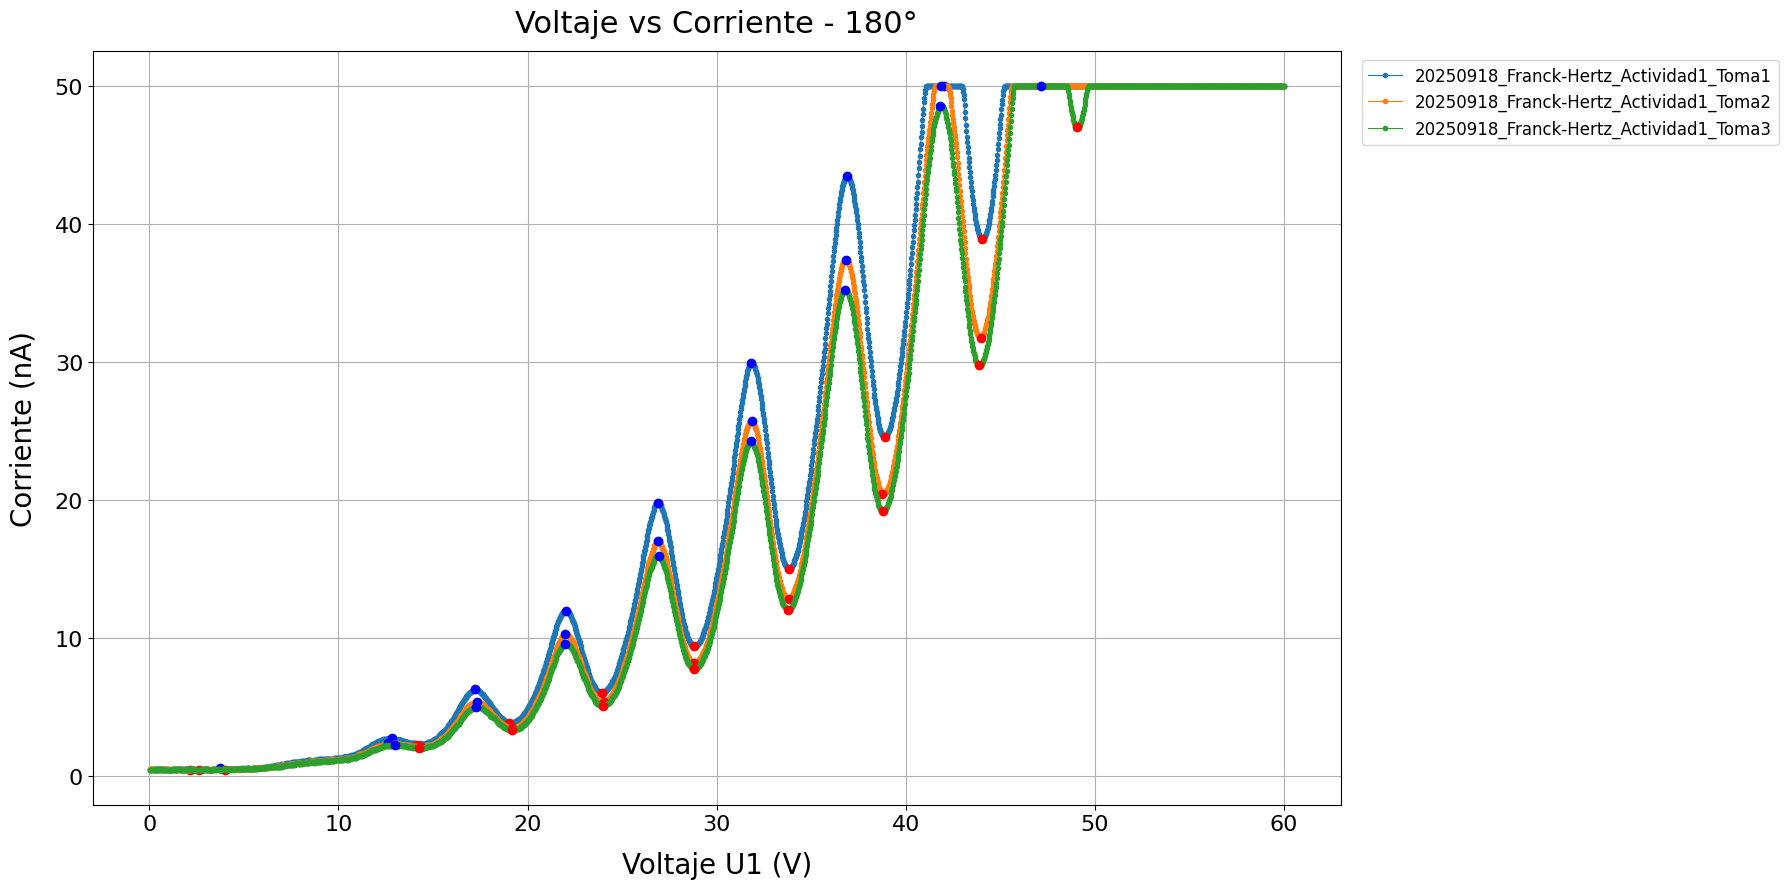

In [65]:
# Carpeta donde están tus archivos
carpeta = Path("Data/Act1/180°")

fig, ax = plt.subplots(figsize=(18, 9))

# Guardar resultados de cada archivo
resultados = {}

for archivo in carpeta.glob("*.txt"):
    voltajes = []
    corrientes = []
    with open(archivo, "r", encoding="utf-8") as f:
        # Saltar encabezados
        try:
            next(f); next(f)
        except StopIteration:
            pass
        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if not voltajes:
        continue

    voltajes = np.array(voltajes)
    corrientes = np.array(corrientes)

    # Detectar máximos y mínimos
    indices_max, _ = find_peaks(corrientes, distance=5, prominence=0.1)
    indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

    # Guardar datos del archivo
    resultados[archivo.stem] = {
        "voltajes": voltajes,
        "corrientes": corrientes,
        "indices_max": indices_max,
        "indices_min": indices_min,
    }

    # Graficar la curva
    ax.plot(voltajes, corrientes, marker="o", markersize=3,
            linewidth=0.8, label=archivo.stem)

    # Marcar máximos y mínimos
    ax.plot(voltajes[indices_max], corrientes[indices_max], "bo", markersize=6)
    ax.plot(voltajes[indices_min], corrientes[indices_min], "ro", markersize=6)

    # Calcular diferencias entre mínimos consecutivos
    if len(indices_min) > 1:
        dif_volt = np.diff(voltajes[indices_min])
        dif_corr = np.diff(corrientes[indices_min])
        print(f"\nArchivo: {archivo.stem}")
        for i in range(len(dif_volt)):
            print(f"  Mínimo {i} -> {i+1}: ΔV = {dif_volt[i]:.4f} V, ΔI = {dif_corr[i]:.4f} nA")

# Configuración de la gráfica
ax.set_xlabel("Voltaje U1 (V)", fontsize=20, labelpad=12)
ax.set_ylabel("Corriente (nA)", fontsize=20, labelpad=12)
ax.set_title("Voltaje vs Corriente - 180°", fontsize=22, pad=14)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

# --- Comparación de picos entre archivos ---
# Cambia estos nombres por los de tus archivos reales
name_ref = "medicion_U2_0"   # archivo con U2=0 V
name_new = "medicion_U2_1p5" # archivo con U2=1.5 V

if name_ref in resultados and name_new in resultados:
    ref = resultados[name_ref]
    new = resultados[name_new]

    if len(ref["indices_max"]) > 0 and len(new["indices_max"]) > 0:
        # Tomar el primer pico máximo como referencia
        idx_ref = ref["indices_max"][0]
        idx_new = new["indices_max"][0]
        pos_ref = ref["voltajes"][idx_ref]
        pos_new = new["voltajes"][idx_new]
        desplazamiento = pos_new - pos_ref
        print(f"\nComparación de picos entre {name_ref} y {name_new}:")
        print(f"  Pos ref: {pos_ref:.3f} V, Pos new: {pos_new:.3f} V")
        print(f"  Desplazamiento Δ = {desplazamiento:.3f} V")
    else:
        print("\nNo se detectaron picos en uno de los archivos para la comparación.")



Archivo: 20250918_Franck-Hertz_Actividad1_Toma1
  Mínimo 0 -> 1: ΔV = 0.7300 V, ΔI = 0.0000 nA
  Mínimo 1 -> 2: ΔV = 0.7600 V, ΔI = 0.0000 nA
  Mínimo 2 -> 3: ΔV = 0.2000 V, ΔI = 0.0000 nA
  Mínimo 3 -> 4: ΔV = 10.4500 V, ΔI = 1.4500 nA
  Mínimo 4 -> 5: ΔV = 0.1400 V, ΔI = 0.0000 nA
  Mínimo 5 -> 6: ΔV = 4.7700 V, ΔI = 1.2100 nA
  Mínimo 6 -> 7: ΔV = 4.7300 V, ΔI = 1.4900 nA
  Mínimo 7 -> 8: ΔV = 4.7700 V, ΔI = 2.2800 nA
  Mínimo 8 -> 9: ΔV = 4.9500 V, ΔI = 3.6300 nA
  Mínimo 9 -> 10: ΔV = 4.9600 V, ΔI = 5.6100 nA
  Mínimo 10 -> 11: ΔV = 5.0500 V, ΔI = 8.1300 nA
  Mínimo 11 -> 12: ΔV = 5.1100 V, ΔI = 12.8700 nA

Archivo: 20250918_Franck-Hertz_Actividad1_Toma2
  Mínimo 0 -> 1: ΔV = 1.1900 V, ΔI = 0.0000 nA
  Mínimo 1 -> 2: ΔV = 3.7600 V, ΔI = 0.0000 nA
  Mínimo 2 -> 3: ΔV = 8.4800 V, ΔI = 1.3400 nA
  Mínimo 3 -> 4: ΔV = 0.3400 V, ΔI = 0.0000 nA
  Mínimo 4 -> 5: ΔV = 5.1000 V, ΔI = 1.0200 nA
  Mínimo 5 -> 6: ΔV = 4.6900 V, ΔI = 1.3800 nA
  Mínimo 6 -> 7: ΔV = 4.7900 V, ΔI = 2.0000 nA
  

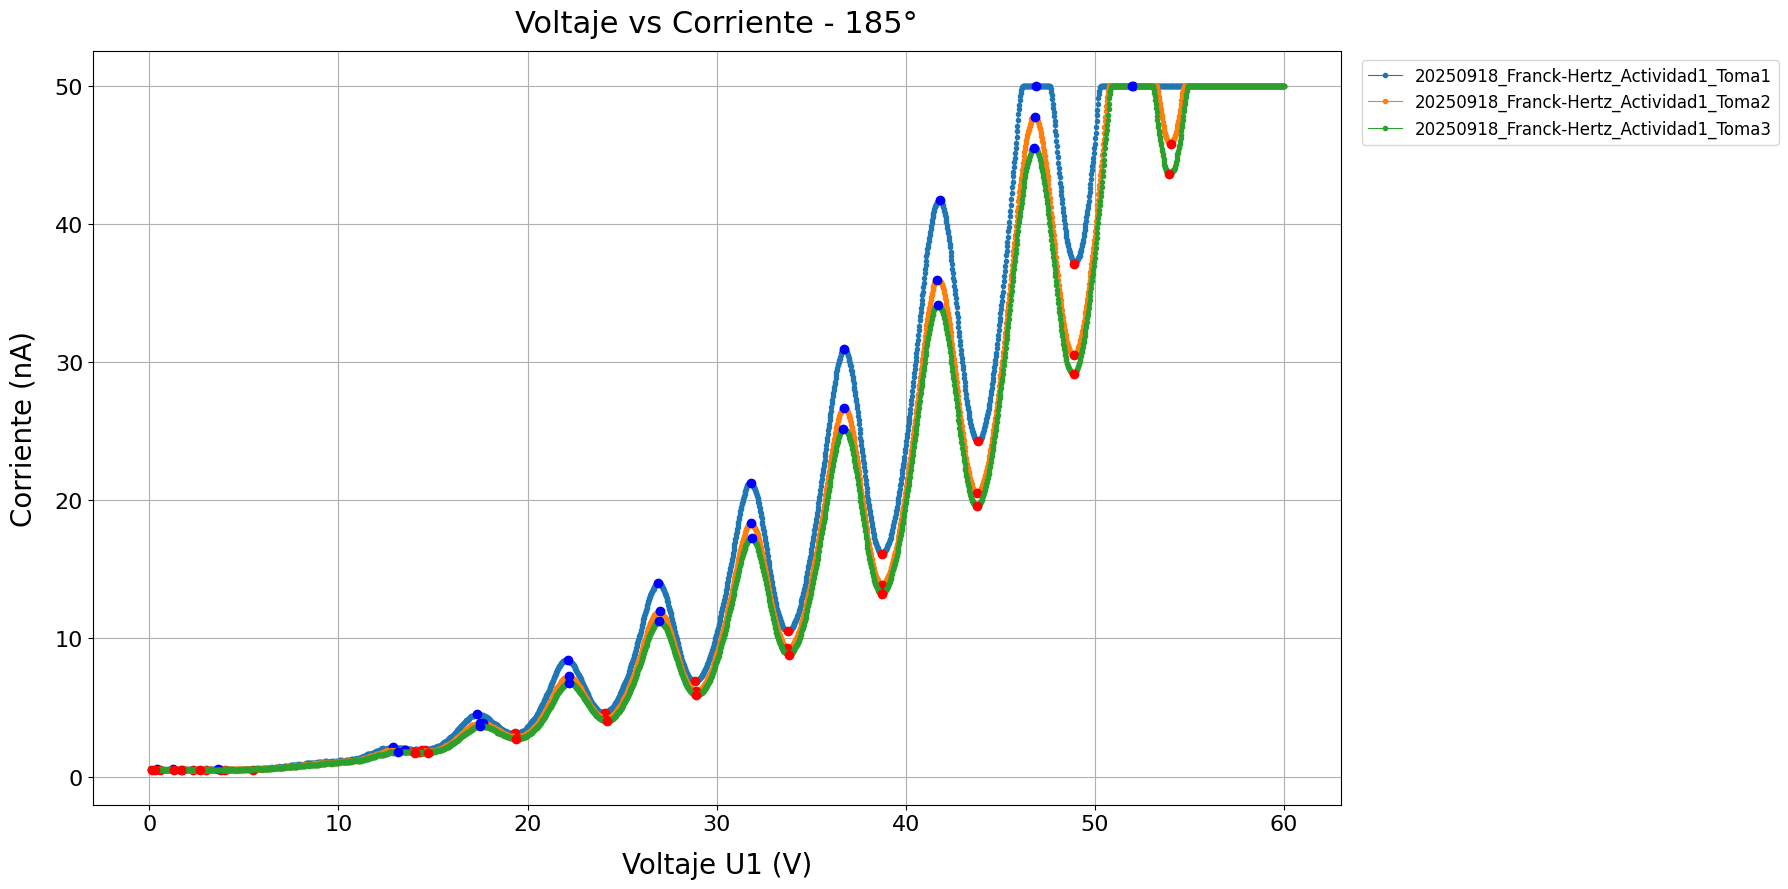

In [66]:
# Carpeta donde están tus archivos
carpeta = Path("Data/Act1/185°")

fig, ax = plt.subplots(figsize=(18, 9))

# Guardar resultados de cada archivo
resultados = {}

for archivo in carpeta.glob("*.txt"):
    voltajes = []
    corrientes = []
    with open(archivo, "r", encoding="utf-8") as f:
        # Saltar encabezados
        try:
            next(f); next(f)
        except StopIteration:
            pass
        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if not voltajes:
        continue

    voltajes = np.array(voltajes)
    corrientes = np.array(corrientes)

    # Detectar máximos y mínimos
    indices_max, _ = find_peaks(corrientes, distance=5, prominence=0.1)
    indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

    # Guardar datos del archivo
    resultados[archivo.stem] = {
        "voltajes": voltajes,
        "corrientes": corrientes,
        "indices_max": indices_max,
        "indices_min": indices_min,
    }

    # Graficar la curva
    ax.plot(voltajes, corrientes, marker="o", markersize=3,
            linewidth=0.8, label=archivo.stem)

    # Marcar máximos y mínimos
    ax.plot(voltajes[indices_max], corrientes[indices_max], "bo", markersize=6)
    ax.plot(voltajes[indices_min], corrientes[indices_min], "ro", markersize=6)

    # Calcular diferencias entre mínimos consecutivos
    if len(indices_min) > 1:
        dif_volt = np.diff(voltajes[indices_min])
        dif_corr = np.diff(corrientes[indices_min])
        print(f"\nArchivo: {archivo.stem}")
        for i in range(len(dif_volt)):
            print(f"  Mínimo {i} -> {i+1}: ΔV = {dif_volt[i]:.4f} V, ΔI = {dif_corr[i]:.4f} nA")

# Configuración de la gráfica
ax.set_xlabel("Voltaje U1 (V)", fontsize=20, labelpad=12)
ax.set_ylabel("Corriente (nA)", fontsize=20, labelpad=12)
ax.set_title("Voltaje vs Corriente - 185°", fontsize=22, pad=14)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

# --- Comparación de picos entre archivos ---
# Cambia estos nombres por los de tus archivos reales
name_ref = "medicion_U2_0"   # archivo con U2=0 V
name_new = "medicion_U2_1p5" # archivo con U2=1.5 V

if name_ref in resultados and name_new in resultados:
    ref = resultados[name_ref]
    new = resultados[name_new]

    if len(ref["indices_max"]) > 0 and len(new["indices_max"]) > 0:
        # Tomar el primer pico máximo como referencia
        idx_ref = ref["indices_max"][0]
        idx_new = new["indices_max"][0]
        pos_ref = ref["voltajes"][idx_ref]
        pos_new = new["voltajes"][idx_new]
        desplazamiento = pos_new - pos_ref
        print(f"\nComparación de picos entre {name_ref} y {name_new}:")
        print(f"  Pos ref: {pos_ref:.3f} V, Pos new: {pos_new:.3f} V")
        print(f"  Desplazamiento Δ = {desplazamiento:.3f} V")
    else:
        print("\nNo se detectaron picos en uno de los archivos para la comparación.")


20250918_Franck-Hertz_Actividad1_Toma1: ΔV promedio = 5.98 V
20250918_Franck-Hertz_Actividad1_Toma2: ΔV promedio = 5.17 V
20250918_Franck-Hertz_Actividad1_Toma3: ΔV promedio = 4.97 V


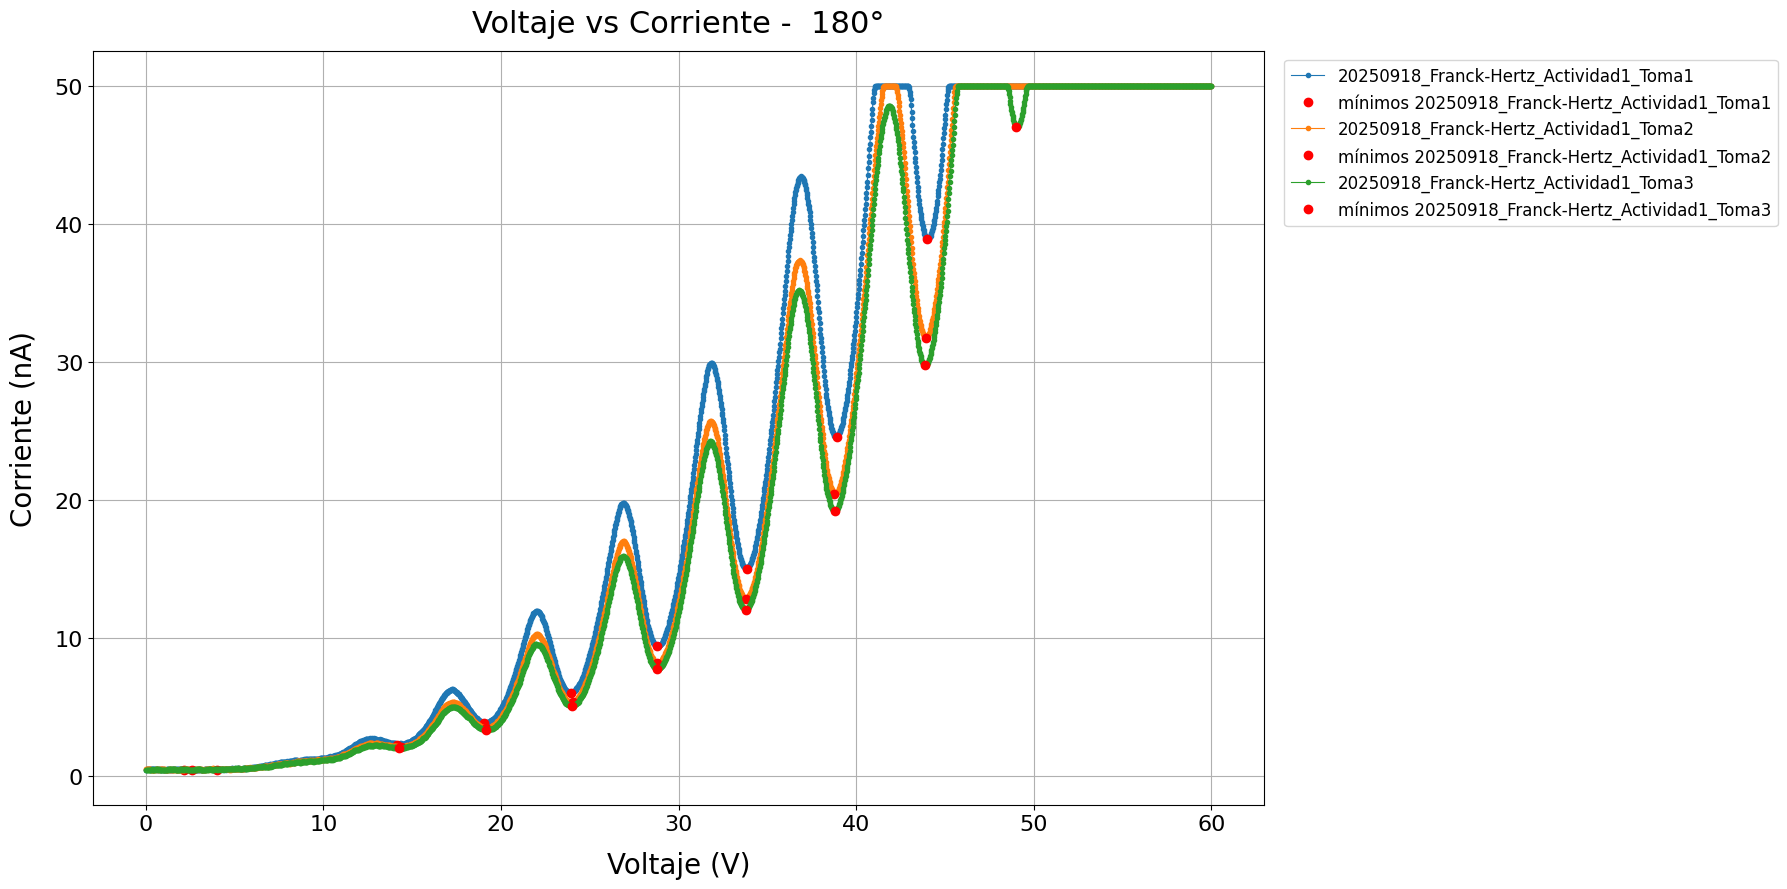

In [ ]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from pathlib import Path

carpeta = Path("Data/Act1/180°")

fig, ax = plt.subplots(figsize=(18, 9))

for archivo in carpeta.glob("*.txt"):
    voltajes = []
    corrientes = []
    with open(archivo, "r", encoding="utf-8") as f:
        try:
            next(f); next(f)
        except StopIteration:
            pass
        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if voltajes:
        voltajes = np.array(voltajes)
        corrientes = np.array(corrientes)

        # --- detectar mínimos ---
        indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

        # calcular distancia en voltaje entre mínimos consecutivos
        deltaV = np.diff(voltajes[indices_min])
        if len(deltaV) > 0:
            print(f"{archivo.stem}: ΔV promedio = {np.mean(deltaV):.2f} V")

        # graficar curva
        ax.plot(voltajes, corrientes, marker="o", markersize=3,
                linewidth=0.8, label=archivo.stem)
        # marcar los mínimos detectados
        ax.plot(voltajes[indices_min], corrientes[indices_min],
                "ro", markersize=6, label=f"mínimos {archivo.stem}")

# Etiquetas y título
ax.set_xlabel("Voltaje (V)", fontsize=20, labelpad=12)
ax.set_ylabel("Corriente (nA)", fontsize=20, labelpad=12)
ax.set_title("Voltaje vs Corriente -  180°", fontsize=22, pad=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

20250918_Franck-Hertz_Actividad1_Toma1: ΔV promedio = 3.88 V
20250918_Franck-Hertz_Actividad1_Toma2: ΔV promedio = 4.45 V
20250918_Franck-Hertz_Actividad1_Toma3: ΔV promedio = 3.84 V


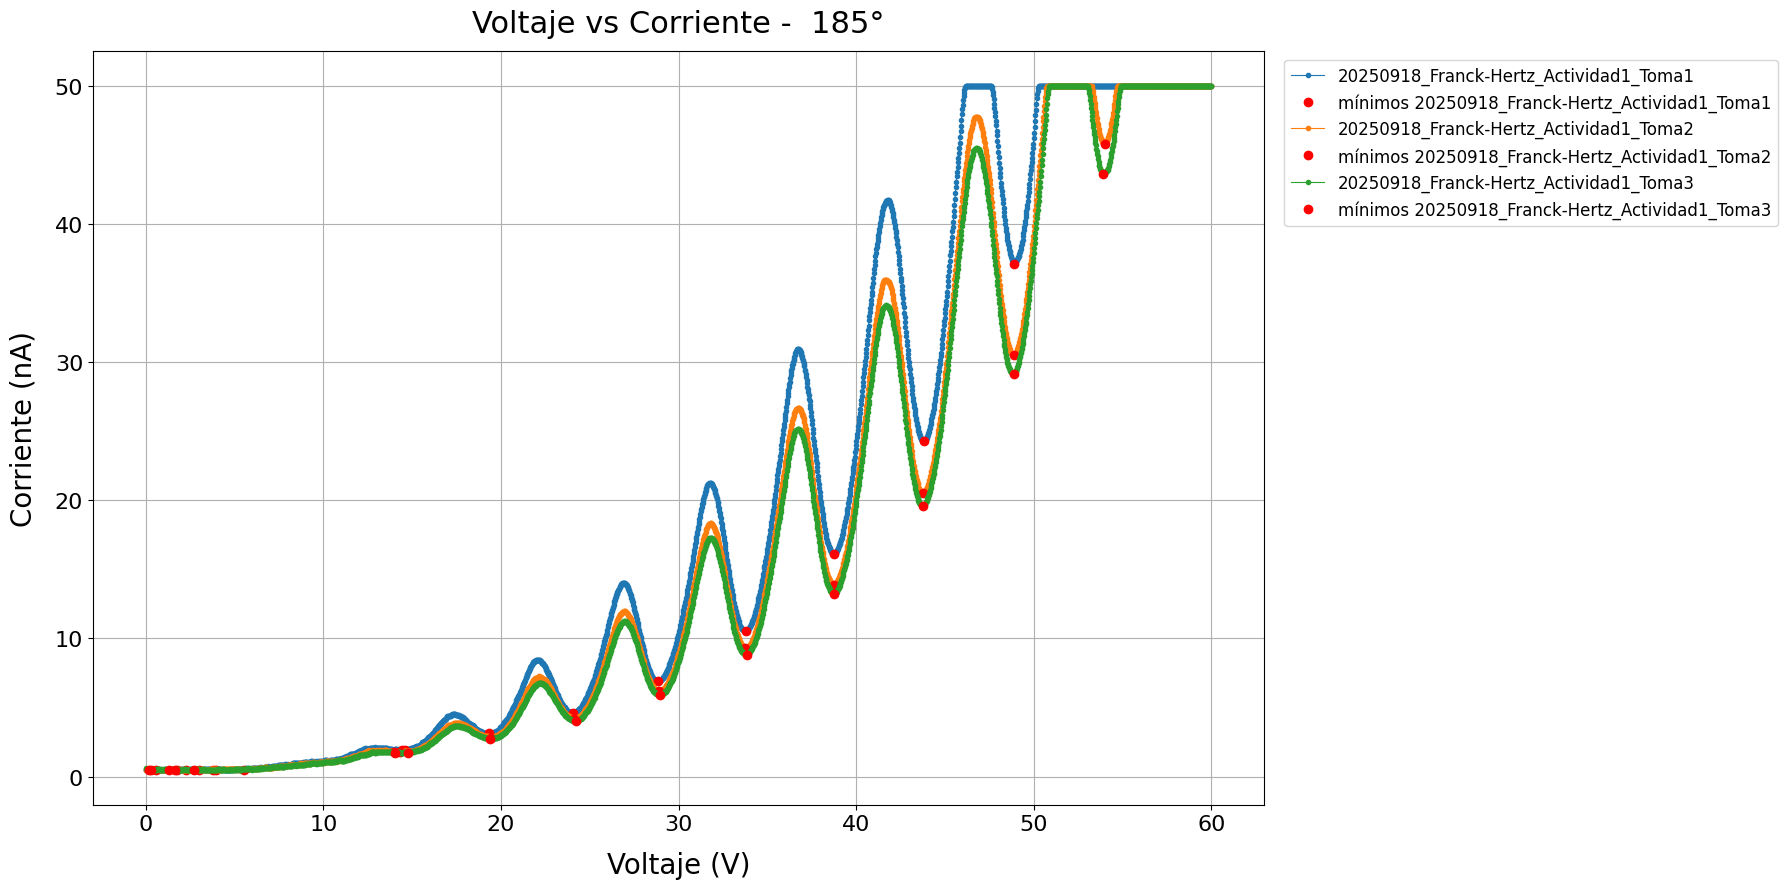

In [68]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from pathlib import Path

carpeta = Path("Data/Act1/185°")

fig, ax = plt.subplots(figsize=(18, 9))

for archivo in carpeta.glob("*.txt"):
    voltajes = []
    corrientes = []
    with open(archivo, "r", encoding="utf-8") as f:
        try:
            next(f); next(f)
        except StopIteration:
            pass
        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if voltajes:
        voltajes = np.array(voltajes)
        corrientes = np.array(corrientes)

        # --- detectar mínimos ---
        indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

        # calcular distancia en voltaje entre mínimos consecutivos
        deltaV = np.diff(voltajes[indices_min])
        if len(deltaV) > 0:
            print(f"{archivo.stem}: ΔV promedio = {np.mean(deltaV):.2f} V")

        # graficar curva
        ax.plot(voltajes, corrientes, marker="o", markersize=3,
                linewidth=0.8, label=archivo.stem)
        # marcar los mínimos detectados
        ax.plot(voltajes[indices_min], corrientes[indices_min],
                "ro", markersize=6, label=f"mínimos {archivo.stem}")

# Etiquetas y título
ax.set_xlabel("Voltaje (V)", fontsize=20, labelpad=12)
ax.set_ylabel("Corriente (nA)", fontsize=20, labelpad=12)
ax.set_title("Voltaje vs Corriente -  185°", fontsize=22, pad=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

Al centrar el pico en el origen y disminuir la temperatura del tubo (apagando la estufa y evitando bajar de 160 °C), se observó que la amplitud de los máximos de corriente disminuye progresivamente y los picos se vuelven menos definidos y más anchos. Esto se explica porque la presión de vapor del mercurio baja con la temperatura, reduciendo la densidad atómica y por tanto la probabilidad de colisiones inelásticas entre electrones y átomos necesarias para producir los picos. En casos de temperatura muy baja algunos picos desaparecen por completo. Se observó además un ligero desplazamiento de las posiciones en voltaje, consistente con un aumento de la longitud libre media de los electrones a menor densidad atómica. Se midieron las posiciones de los máximos y se calculó la separación promedio $$\bar{\Delta V}$$ se estimó la energía de excitación experimental como $$E \approx \bar{\Delta V} \; \text{eV}$$ la cual puede compararse con el valor teórico.



---

## Actividad 2

1. Tome varias series de datos con la misma temperatura, procure que las variaciones en esta sean m´ınimas. ¿C´omo se comparan las diferentes gr´aficas? ¿C´omo afectan estas peque˜nas fluctuaciones en la temperatura a sus resultados? ¿Se justifica un an´alisis estad´ıstico?

2. Para valores de UH y U2 constantes registre la corriente IA y el voltaje U1 para diferentes temperaturas en el intervalo 165◦C-185◦C. 

3. Con los datos para cada temperatura calcule la distancia entre m´ınimos y comp´arela con el valor esperado de 4,67eV . ¿ C´omo puede explicar las discrepancias. 

4. Concentr´andose en valores menores registre d´onde ocurre el primer m´ınimo. ¿Por qu´e no sucede en 4,67eV ? ¿Qu´e podr´ıa calcular sabiendo la posici´on del primer m´ınimo? (Ayuda: tenga en cuenta el voltaje de retardo U2.)

5.Para un valor de temperatura fijo cambie el valor de U2 (entre 1V y 2V) y registre los valores medidos de IA en funci´on de U1. Haga una sola gr´afica con sus resultados.

6. Para un valor de U2 y temperatura fijos. Cambie el valor de UH en el rango (6,3 ± 0,5)V . Explique c´omo cambia la curva IA vs U1 y sustente su respuesta en t´erminos de la emisi´on termoi´onica, la temperatura del c´atodo y la distribuci´on de Maxwell- Boltzmann de los electrones que de all´ı son emitidos. Use esta respuesta para sus-
tentar el ancho en los valles y picos del patr´on observado.

7. Con las mediciones que ya ha realizado haga una gr´afica de distancia entre m´ınimos
en funci´on del orden del m´ınimo. ¿Observa este comportamiento creciente lineal? (Las diferencias son relativamente peque˜nas as´ı que procure hacer las mediciones con la mayor precisi´on posible). Para cada temperatura obtenga una regresi´on lineal (entre distancia entre m´ınimos y orden del m´ınimo) y con el valor de la pendiente
calcule el camino libre medio experimental con la ecuaci´on 
¯`exp = L
2Ea
d∆E(n)
dn , (8)
comparando sus resultados con los que obtuvo en el punto 2 del Ejercicio 3).
Adicionalmente, con las regresiones que realiz´o, calcule el valor de Ea mediante la
evaluaci´on de ∆E(0,5), compare su valor con el valor reportado de 4.67eV. Use un
valor de L = 12cm.

## 1


Archivo: 20250918_Franck-Hertz_Actividad2_Toma10(175°, UH = 5,9V)
  Mínimo 0 -> 1: ΔV = 4.8100 V, ΔI = 0.5500 nA
  Mínimo 1 -> 2: ΔV = 4.8100 V, ΔI = 0.6400 nA
  Mínimo 2 -> 3: ΔV = 4.8100 V, ΔI = 0.9900 nA
  Mínimo 3 -> 4: ΔV = 5.0000 V, ΔI = 1.4500 nA
  Mínimo 4 -> 5: ΔV = 5.2300 V, ΔI = 2.2300 nA
  Mínimo 5 -> 6: ΔV = 5.0100 V, ΔI = 4.7400 nA

Archivo: 20250918_Franck-Hertz_Actividad2_Toma11(175°, UH = 6V)
  Mínimo 0 -> 1: ΔV = 5.0000 V, ΔI = 0.7800 nA
  Mínimo 1 -> 2: ΔV = 4.4200 V, ΔI = 0.8800 nA
  Mínimo 2 -> 3: ΔV = 5.0100 V, ΔI = 1.3000 nA
  Mínimo 3 -> 4: ΔV = 5.0000 V, ΔI = 2.0800 nA
  Mínimo 4 -> 5: ΔV = 5.2300 V, ΔI = 3.0200 nA
  Mínimo 5 -> 6: ΔV = 5.0100 V, ΔI = 5.7400 nA

Archivo: 20250918_Franck-Hertz_Actividad2_Toma12(175°, UH = 6,1V)
  Mínimo 0 -> 1: ΔV = 4.6200 V, ΔI = 0.8400 nA
  Mínimo 1 -> 2: ΔV = 4.8100 V, ΔI = 1.1300 nA
  Mínimo 2 -> 3: ΔV = 4.8100 V, ΔI = 1.7000 nA
  Mínimo 3 -> 4: ΔV = 5.0000 V, ΔI = 2.5600 nA
  Mínimo 4 -> 5: ΔV = 5.0400 V, ΔI = 3.7000 nA
  

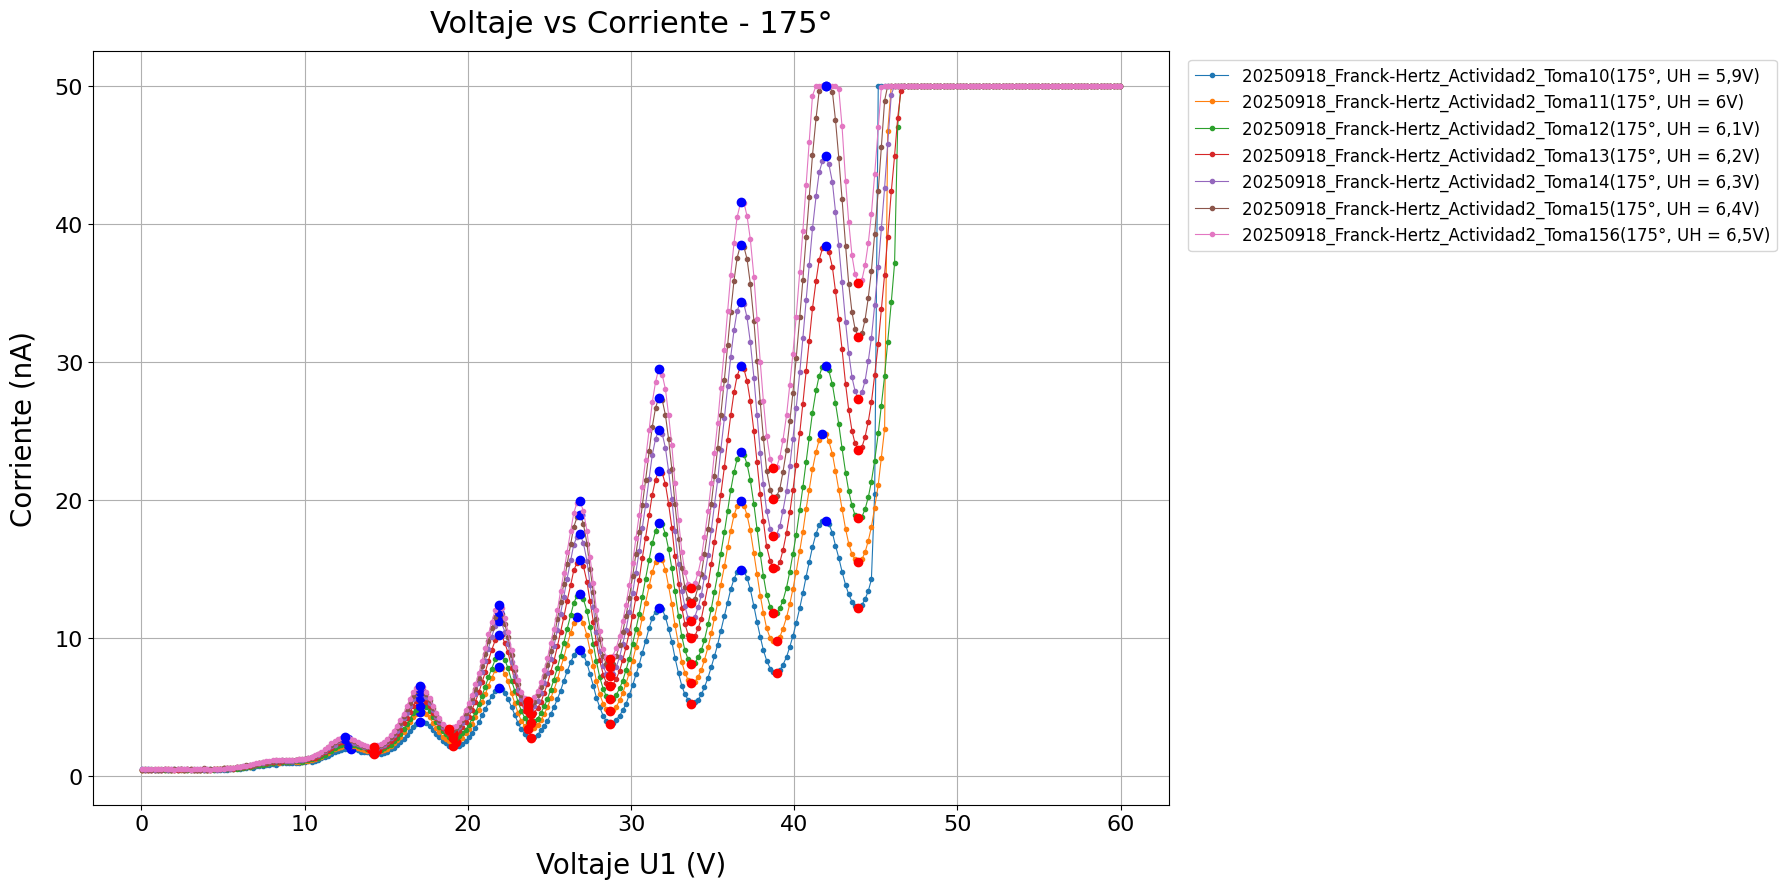

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks

# Carpeta donde están tus archivos
carpeta = Path("Data/Act2/Temperatura Constante")

fig, ax = plt.subplots(figsize=(18, 9))

# Guardar resultados de cada archivo
resultados = {}

# Tomar solo los primeros 7 archivos ordenados
archivos = sorted(list(carpeta.glob("*.txt")))[:7]

# Número máximo de puntos por curva (submuestreo)
Nmax = 300

for archivo in archivos:
    voltajes = []
    corrientes = []

    with open(archivo, "r", encoding="utf-8") as f:
        # Saltar encabezados
        try:
            next(f); next(f)
        except StopIteration:
            pass

        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if not voltajes:
        continue

    voltajes = np.array(voltajes)
    corrientes = np.array(corrientes)

    # --- Submuestreo ---
    if len(voltajes) > Nmax:
        idx = np.linspace(0, len(voltajes)-1, Nmax, dtype=int)
        voltajes = voltajes[idx]
        corrientes = corrientes[idx]

    # Detectar máximos y mínimos
    indices_max, _ = find_peaks(corrientes, distance=5, prominence=0.1)
    indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

    # Guardar datos del archivo
    resultados[archivo.stem] = {
        "voltajes": voltajes,
        "corrientes": corrientes,
        "indices_max": indices_max,
        "indices_min": indices_min,
    }

    # Graficar la curva
    ax.plot(voltajes, corrientes, marker="o", markersize=3,
            linewidth=0.8, label=archivo.stem)

    # Marcar máximos y mínimos
    ax.plot(voltajes[indices_max], corrientes[indices_max], "bo", markersize=6)
    ax.plot(voltajes[indices_min], corrientes[indices_min], "ro", markersize=6)

    # Calcular diferencias entre mínimos consecutivos
    if len(indices_min) > 1:
        dif_volt = np.diff(voltajes[indices_min])
        dif_corr = np.diff(corrientes[indices_min])
        print(f"\nArchivo: {archivo.stem}")
        for i in range(len(dif_volt)):
            print(f"  Mínimo {i} -> {i+1}: ΔV = {dif_volt[i]:.4f} V, ΔI = {dif_corr[i]:.4f} nA")

# Configuración de la gráfica
ax.set_xlabel("Voltaje U1 (V)", fontsize=20, labelpad=12)
ax.set_ylabel("Corriente (nA)", fontsize=20, labelpad=12)
ax.set_title("Voltaje vs Corriente - 175°", fontsize=22, pad=14)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()


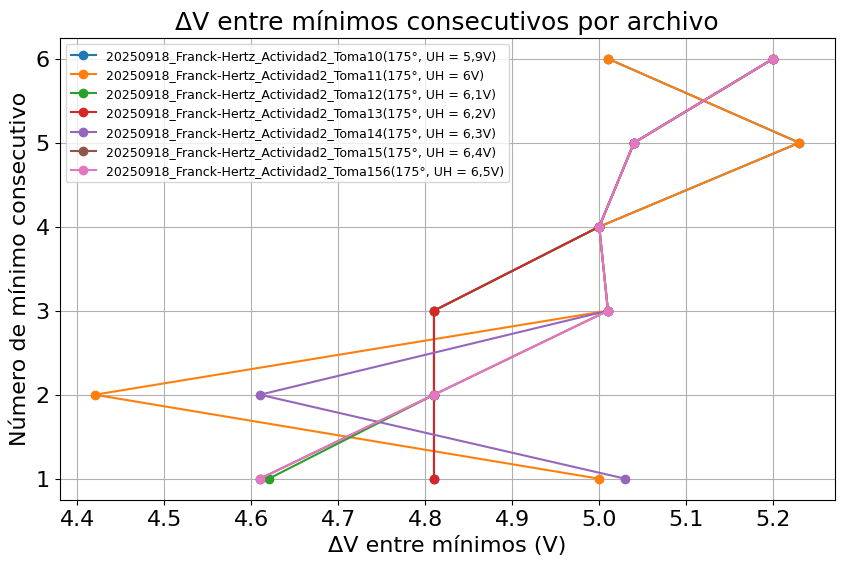

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks

# Carpeta donde están tus archivos
carpeta = Path("Data/Act2/Temperatura Constante")

# Tomar solo los primeros 7 archivos ordenados
archivos = sorted(list(carpeta.glob("*.txt")))[:7]

# Número máximo de puntos por curva (submuestreo)
Nmax = 300

plt.figure(figsize=(10, 6))

for archivo in archivos:
    voltajes = []
    corrientes = []

    with open(archivo, "r", encoding="utf-8") as f:
        # Saltar encabezados
        try:
            next(f); next(f)
        except StopIteration:
            pass

        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if not voltajes:
        continue

    voltajes = np.array(voltajes)
    corrientes = np.array(corrientes)

    # --- Submuestreo ---
    if len(voltajes) > Nmax:
        idx = np.linspace(0, len(voltajes)-1, Nmax, dtype=int)
        voltajes = voltajes[idx]
        corrientes = corrientes[idx]

    # Detectar mínimos
    indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

    if len(indices_min) > 1:
        dif_volt = np.diff(voltajes[indices_min])

        # Graficar ΔV en el eje X y número de mínimo en el eje Y
        plt.plot(
            dif_volt,
            range(1, len(dif_volt)+1),
            "o-",
            label=archivo.stem
        )

# Configuración de la gráfica
plt.xlabel("ΔV entre mínimos (V)", fontsize=16)
plt.ylabel("Número de mínimo consecutivo", fontsize=16)
plt.title("ΔV entre mínimos consecutivos por archivo", fontsize=18)
plt.legend(loc="best", fontsize=9)
plt.grid(True)
plt.show()


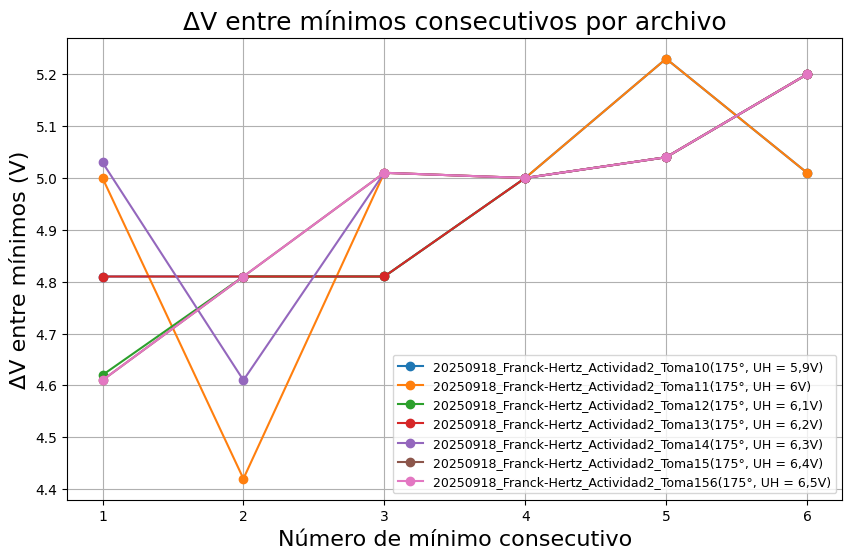

In [3]:
# Carpeta donde están tus archivos
carpeta = Path("Data/Act2/Temperatura Constante")

# Tomar solo los primeros 7 archivos ordenados
archivos = sorted(list(carpeta.glob("*.txt")))[:7]

# Número máximo de puntos por curva (submuestreo)
Nmax = 300

plt.figure(figsize=(10, 6))

for archivo in archivos:
    voltajes = []
    corrientes = []

    with open(archivo, "r", encoding="utf-8") as f:
        # Saltar encabezados
        try:
            next(f); next(f)
        except StopIteration:
            pass

        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if not voltajes:
        continue

    voltajes = np.array(voltajes)
    corrientes = np.array(corrientes)

    # --- Submuestreo ---
    if len(voltajes) > Nmax:
        idx = np.linspace(0, len(voltajes)-1, Nmax, dtype=int)
        voltajes = voltajes[idx]
        corrientes = corrientes[idx]

    # Detectar mínimos
    indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

    if len(indices_min) > 1:
        dif_volt = np.diff(voltajes[indices_min])

        # Graficar ΔV vs número de mínimo para este archivo
        plt.plot(
            range(1, len(dif_volt)+1),
            dif_volt,
            "o-",
            label=archivo.stem
        )

# Configuración de la gráfica
plt.xlabel("Número de mínimo consecutivo", fontsize=16)
plt.ylabel("ΔV entre mínimos (V)", fontsize=16)
plt.title("ΔV entre mínimos consecutivos por archivo", fontsize=18)
plt.legend(loc="best", fontsize=9)
plt.grid(True)
plt.show()



Archivo: 20250918_Franck-Hertz_Actividad2_Toma6 (175°, U2 = 1V)
  Mínimo 0 -> 1: ΔV = 4.8100 V, ΔI = 2.3700 nA
  Mínimo 1 -> 2: ΔV = 4.8100 V, ΔI = 3.2800 nA
  Mínimo 2 -> 3: ΔV = 5.0300 V, ΔI = 4.6000 nA
  Mínimo 3 -> 4: ΔV = 5.0100 V, ΔI = 5.4900 nA
  Mínimo 4 -> 5: ΔV = 5.2300 V, ΔI = 7.0400 nA
  Mínimo 5 -> 6: ΔV = 5.0000 V, ΔI = 10.9000 nA

Archivo: 20250918_Franck-Hertz_Actividad2_Toma7 (175°, U2 = 1.5V)
  Mínimo 0 -> 1: ΔV = 4.8100 V, ΔI = 1.0900 nA
  Mínimo 1 -> 2: ΔV = 4.8100 V, ΔI = 1.4400 nA
  Mínimo 2 -> 3: ΔV = 4.8100 V, ΔI = 2.1100 nA
  Mínimo 3 -> 4: ΔV = 5.0300 V, ΔI = 3.2700 nA
  Mínimo 4 -> 5: ΔV = 5.0100 V, ΔI = 4.5900 nA
  Mínimo 5 -> 6: ΔV = 5.0100 V, ΔI = 7.2600 nA
  Mínimo 6 -> 7: ΔV = 5.2200 V, ΔI = 14.5300 nA

Archivo: 20250918_Franck-Hertz_Actividad2_Toma8(175°, U2 = 2V)
  Mínimo 0 -> 1: ΔV = 4.8100 V, ΔI = 0.5800 nA
  Mínimo 1 -> 2: ΔV = 4.8100 V, ΔI = 0.7000 nA
  Mínimo 2 -> 3: ΔV = 4.8100 V, ΔI = 1.0900 nA
  Mínimo 3 -> 4: ΔV = 5.0300 V, ΔI = 1.7400 nA
  M

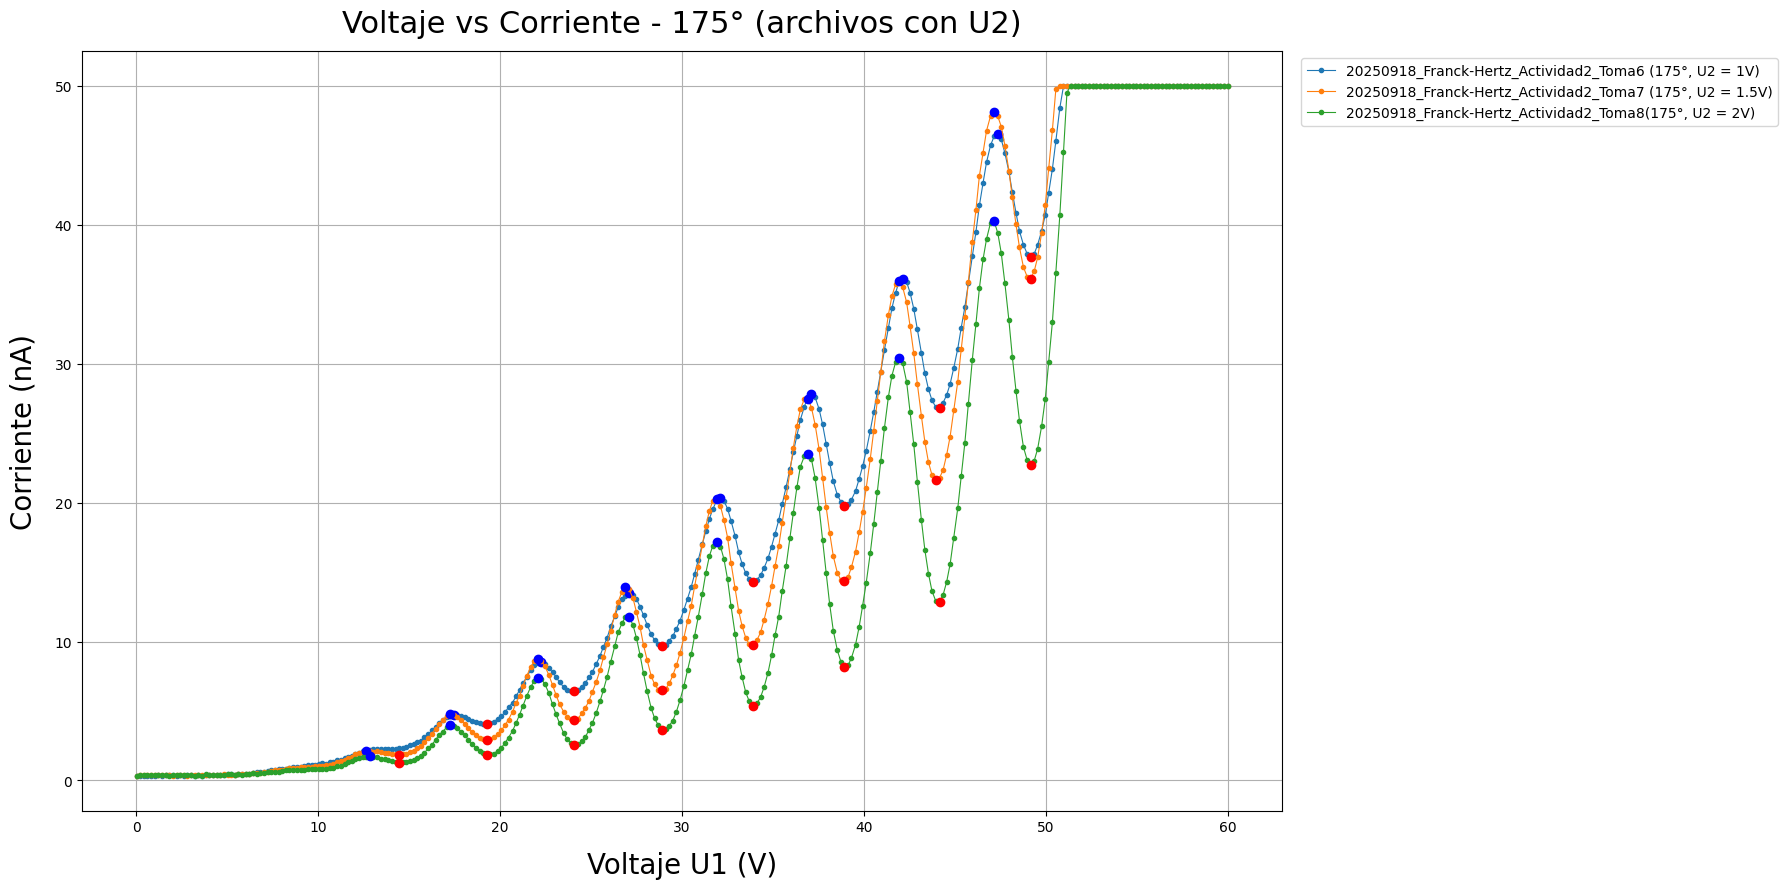

In [4]:
# Carpeta donde están tus archivos
carpeta = Path("Data/Act2/Temperatura Constante")

fig, ax = plt.subplots(figsize=(18, 9))

# Guardar resultados de cada archivo
resultados = {}

# --- Filtrar solo archivos que tengan 'U2' en el nombre ---
archivos = sorted([a for a in carpeta.glob("*.txt") if "U2" in a.stem])

# Número máximo de puntos por curva (submuestreo)
Nmax = 300

for archivo in archivos:
    voltajes = []
    corrientes = []

    with open(archivo, "r", encoding="utf-8") as f:
        # Saltar encabezados
        try:
            next(f); next(f)
        except StopIteration:
            pass

        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if not voltajes:
        continue

    voltajes = np.array(voltajes)
    corrientes = np.array(corrientes)

    # --- Submuestreo ---
    if len(voltajes) > Nmax:
        idx = np.linspace(0, len(voltajes)-1, Nmax, dtype=int)
        voltajes = voltajes[idx]
        corrientes = corrientes[idx]

    # Detectar máximos y mínimos
    indices_max, _ = find_peaks(corrientes, distance=5, prominence=0.1)
    indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

    # Guardar datos del archivo
    resultados[archivo.stem] = {
        "voltajes": voltajes,
        "corrientes": corrientes,
        "indices_max": indices_max,
        "indices_min": indices_min,
    }

    # Graficar la curva
    ax.plot(voltajes, corrientes, marker="o", markersize=3,
            linewidth=0.8, label=archivo.stem)

    # Marcar máximos y mínimos
    ax.plot(voltajes[indices_max], corrientes[indices_max], "bo", markersize=6)
    ax.plot(voltajes[indices_min], corrientes[indices_min], "ro", markersize=6)

    # Calcular diferencias entre mínimos consecutivos
    if len(indices_min) > 1:
        dif_volt = np.diff(voltajes[indices_min])
        dif_corr = np.diff(corrientes[indices_min])
        print(f"\nArchivo: {archivo.stem}")
        for i in range(len(dif_volt)):
            print(f"  Mínimo {i} -> {i+1}: ΔV = {dif_volt[i]:.4f} V, ΔI = {dif_corr[i]:.4f} nA")

# Configuración de la gráfica
ax.set_xlabel("Voltaje U1 (V)", fontsize=20, labelpad=12)
ax.set_ylabel("Corriente (nA)", fontsize=20, labelpad=12)
ax.set_title("Voltaje vs Corriente - 175° (archivos con U2)", fontsize=22, pad=14)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()


## 2.


Archivo: 20250918_Franck-Hertz_Actividad2_Toma1 (165°)
  Mínimo 0 -> 1: ΔV = 5.0300 V, ΔI = 1.5100 nA
  Mínimo 1 -> 2: ΔV = 4.8100 V, ΔI = 2.1500 nA
  Mínimo 2 -> 3: ΔV = 5.0000 V, ΔI = 3.2900 nA
  Mínimo 3 -> 4: ΔV = 5.0300 V, ΔI = 5.4800 nA
  Mínimo 4 -> 5: ΔV = 5.0100 V, ΔI = 8.9700 nA
  Mínimo 5 -> 6: ΔV = 5.2300 V, ΔI = 15.8000 nA

Archivo: 20250918_Franck-Hertz_Actividad2_Toma2 (170°)
  Mínimo 0 -> 1: ΔV = 4.8300 V, ΔI = 1.5400 nA
  Mínimo 1 -> 2: ΔV = 4.8100 V, ΔI = 2.4500 nA
  Mínimo 2 -> 3: ΔV = 5.0100 V, ΔI = 3.8800 nA
  Mínimo 3 -> 4: ΔV = 5.0000 V, ΔI = 6.5900 nA
  Mínimo 4 -> 5: ΔV = 5.2300 V, ΔI = 11.1500 nA
  Mínimo 5 -> 6: ΔV = 5.2300 V, ΔI = 21.5200 nA

Archivo: 20250918_Franck-Hertz_Actividad2_Toma3 (175°)
  Mínimo 0 -> 1: ΔV = 4.8300 V, ΔI = 1.3300 nA
  Mínimo 1 -> 2: ΔV = 4.8100 V, ΔI = 2.0400 nA
  Mínimo 2 -> 3: ΔV = 5.0100 V, ΔI = 3.0700 nA
  Mínimo 3 -> 4: ΔV = 5.0000 V, ΔI = 5.1300 nA
  Mínimo 4 -> 5: ΔV = 5.2300 V, ΔI = 7.9500 nA
  Mínimo 5 -> 6: ΔV = 5.2300 V

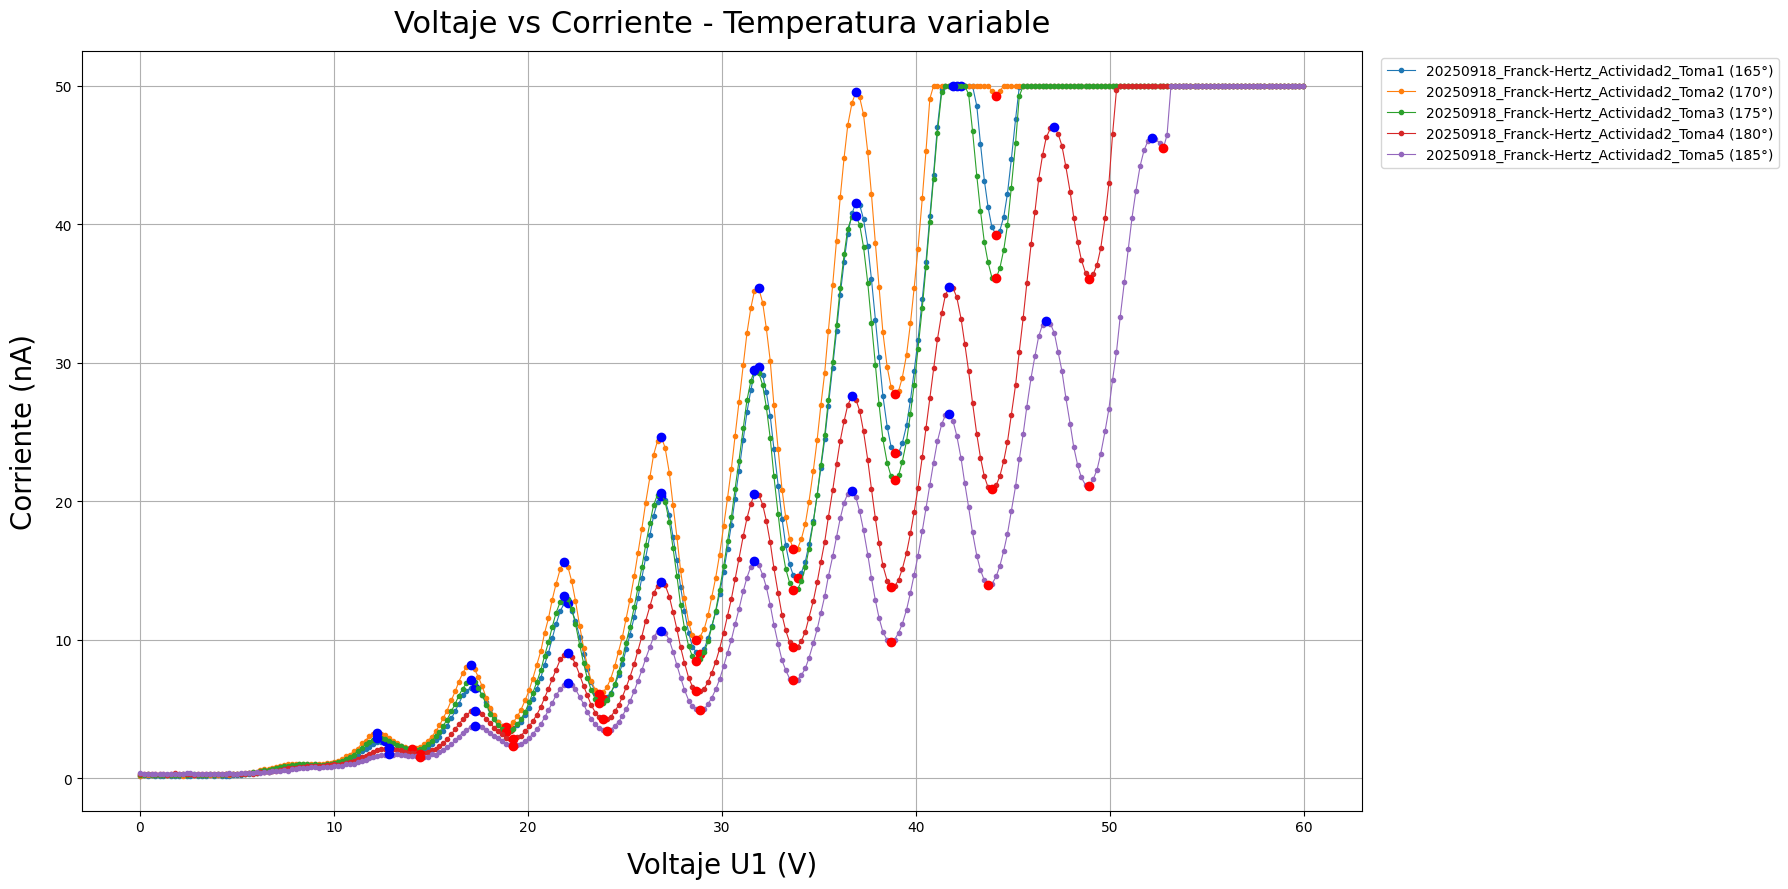

In [5]:
# Carpeta donde están tus archivos
carpeta = Path("Data/Act2/Temperatura Variante")

fig, ax = plt.subplots(figsize=(18, 9))

# Guardar resultados de cada archivo
resultados = {}

# Tomar solo los primeros 7 archivos ordenados
archivos = sorted(list(carpeta.glob("*.txt")))[:7]

# Número máximo de puntos por curva (submuestreo)
Nmax = 300

for archivo in archivos:
    voltajes = []
    corrientes = []

    with open(archivo, "r", encoding="utf-8") as f:
        # Saltar encabezados
        try:
            next(f); next(f)
        except StopIteration:
            pass

        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except Exception:
                continue
            voltajes.append(v)
            corrientes.append(i)

    if not voltajes:
        continue

    voltajes = np.array(voltajes)
    corrientes = np.array(corrientes)

    # --- Submuestreo ---
    if len(voltajes) > Nmax:
        idx = np.linspace(0, len(voltajes)-1, Nmax, dtype=int)
        voltajes = voltajes[idx]
        corrientes = corrientes[idx]

    # Detectar máximos y mínimos
    indices_max, _ = find_peaks(corrientes, distance=5, prominence=0.1)
    indices_min, _ = find_peaks(-corrientes, distance=5, prominence=0.1)

    # Guardar datos del archivo
    resultados[archivo.stem] = {
        "voltajes": voltajes,
        "corrientes": corrientes,
        "indices_max": indices_max,
        "indices_min": indices_min,
    }

    # Graficar la curva
    ax.plot(voltajes, corrientes, marker="o", markersize=3,
            linewidth=0.8, label=archivo.stem)

    # Marcar máximos y mínimos
    ax.plot(voltajes[indices_max], corrientes[indices_max], "bo", markersize=6)
    ax.plot(voltajes[indices_min], corrientes[indices_min], "ro", markersize=6)

    # Calcular diferencias entre mínimos consecutivos
    if len(indices_min) > 1:
        dif_volt = np.diff(voltajes[indices_min])
        dif_corr = np.diff(corrientes[indices_min])
        print(f"\nArchivo: {archivo.stem}")
        for i in range(len(dif_volt)):
            print(f"  Mínimo {i} -> {i+1}: ΔV = {dif_volt[i]:.4f} V, ΔI = {dif_corr[i]:.4f} nA")

# Configuración de la gráfica
ax.set_xlabel("Voltaje U1 (V)", fontsize=20, labelpad=12)
ax.set_ylabel("Corriente (nA)", fontsize=20, labelpad=12)
ax.set_title("Voltaje vs Corriente - Temperatura variable", fontsize=22, pad=14)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()


## 3.

A partir de la separación entre mínimos obtenida en las curvas de corriente contra voltaje, se determinó un valor promedio de ΔV≈5.02V, con una dispersión típica de ±0.15V. Este resultado se encuentra cercano, aunque sistemáticamente mayor, al valor esperado de 4.67eV correspondiente a la primera energía de excitación del mercurio. La discrepancia, de aproximadamente un 7–8%, puede atribuirse a diversos factores experimentales: la existencia de un potencial de contacto entre electrodos que introduce un desplazamiento adicional en la posición de los picos; la distribución inicial de energías de los electrones y el ensanchamiento asociado a la temperatura; la ocurrencia de colisiones múltiples en picos de orden superior; así como posibles errores instrumentales en la calibración del voltaje o en la identificación de los mínimos. En conjunto, estas limitaciones experimentales explican el ligero corrimiento respecto al valor teórico, manteniendo sin embargo la consistencia general del resultado con la predicción del modelo de Franck-Hertz.

## 4.

---

## Para Considerar

1. ¿En qu´e magnitud cree que afectan las siguientes variables en el experimento? 
- Campo magn´etico terrestre o campos electromagn´eticos externos. 
-La condici´on de vac´ıo en el tubo de Frank-Hertz.
-No uniformidad del campo el´ectrico que acelera los electrones.
-No uniformidad de la temperatura en la estufa
2. ¿C´omo podr´ıa (si es posible) minimizar los efectos de las variables mencionadas en
el punto anterior?